In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
file_path = "datasets_with_attacks/Datasets with attacks/Combined/Vehicle A/Vehicle A - Replay 0x181, 0x161, 0x1a5, Fuzzing 0x244, 0x284, 0x354 - IDs_Datafield_Classification.csv"
df = pd.read_csv(file_path, sep=';', header=None)

def hex_converter(val):
    if isinstance(val, str):
        try: return int(val, 16)
        except: return 0
    return val

X = df.iloc[:, :-1].applymap(hex_converter)
y = df.iloc[:, -1]

print("Data Loaded Successfully!")
print(f"Dataset shape: {df.shape}")

C:\Users\W10\AppData\Local\Temp\ipykernel_12180\90499523.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df.iloc[:, :-1].applymap(hex_converter)


Data Loaded Successfully!
Dataset shape: (1327919, 14)


In [4]:
print("Class distribution:")
print(y.value_counts()) 

attack_percentage = (y.sum() / len(y)) * 100
print(f"Percentage of attacks in dataset: {attack_percentage:.2f}%")

Class distribution:
13
0    1132878
1     195041
Name: count, dtype: int64
Percentage of attacks in dataset: 14.69%


In [5]:
import pandas as pd
import numpy as np
import sys
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

file_path = "datasets_with_attacks/Datasets with attacks/Combined/Vehicle A/Vehicle A - Replay 0x181, 0x161, 0x1a5, Fuzzing 0x244, 0x284, 0x354 - IDs_Datafield_Classification.csv"
df = pd.read_csv(file_path, sep=';', header=None)

def hex_converter(val):
    if isinstance(val, str):
        try: return int(val, 16)
        except: return 0
    return val

X = df.iloc[:, :-1].applymap(hex_converter)
y = df.iloc[:, -1]                          

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf = RandomForestClassifier(
    n_estimators=100,           
    max_depth=12,              
    min_samples_split=20,       
    max_leaf_nodes=500,         
    random_state=42, 
    class_weight='balanced',    
    n_jobs=-1                   
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

model_size_bytes = sys.getsizeof(pickle.dumps(clf))
print(f"\nOPTIMIZED Model Memory Footprint: {model_size_bytes / 1024:.2f} KB")

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"False Negatives (Missed Attacks): {fn} - Target: Minimize for Safety")

C:\Users\W10\AppData\Local\Temp\ipykernel_12180\843071571.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = df.iloc[:, :-1].applymap(hex_converter)


Accuracy: 0.9121

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95    226729
           1       0.65      0.89      0.75     38855

    accuracy                           0.91    265584
   macro avg       0.81      0.90      0.85    265584
weighted avg       0.93      0.91      0.92    265584


OPTIMIZED Model Memory Footprint: 6099.25 KB
False Negatives (Missed Attacks): 4375 - Target: Minimize for Safety



--- DETAILED PERFORMANCE REPORT ---
              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95    226729
   Intrusion       0.65      0.89      0.75     38855

    accuracy                           0.91    265584
   macro avg       0.81      0.90      0.85    265584
weighted avg       0.93      0.91      0.92    265584



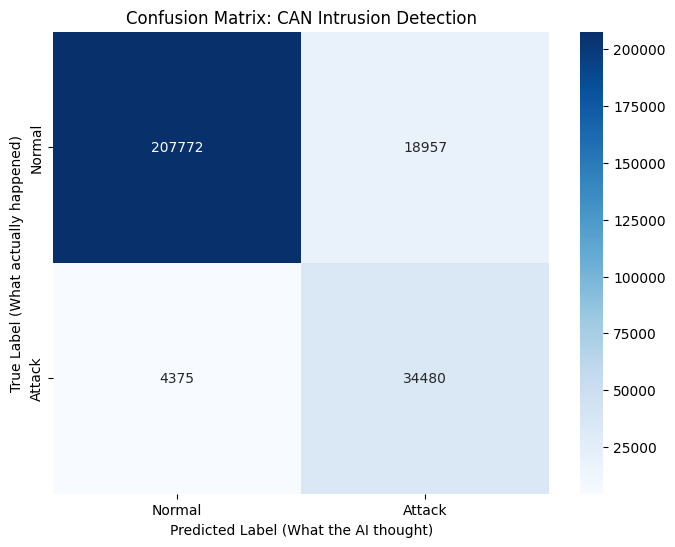

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n--- DETAILED PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Intrusion']))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix: CAN Intrusion Detection')
plt.xlabel('Predicted Label (What the AI thought)')
plt.ylabel('True Label (What actually happened)')
plt.show()

d:\Faculta\M AN 2 SEM 1\ESS\CAN_Intrusion_Project\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


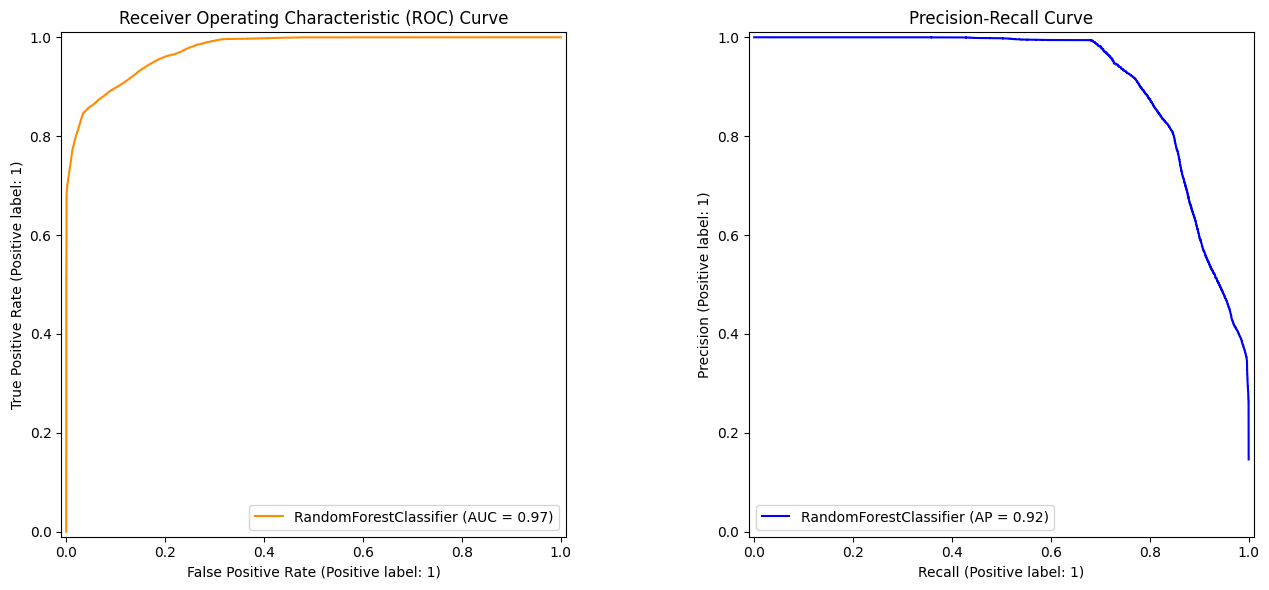

In [7]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

RocCurveDisplay.from_estimator(clf, X_test, y_test, ax=ax1, color='darkorange')
ax1.set_title("Receiver Operating Characteristic (ROC) Curve")

PrecisionRecallDisplay.from_estimator(clf, X_test, y_test, ax=ax2, color='blue')
ax2.set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()